# T3 - Métodos de aprendizaje semi-supervisado



En esta práctica vamos a ver dos ejemplos: el primero, cómo funciona Naive Bayes con datos sin etiquetar, y el segundo, cómo podemos mejorar la versión básica del Naive Bayes aprendiendo un mejor modelo iterativamente mediante el algoritmo de EM.

## Naive Bayes SIN datos sin etiquetar

Realizamos los imports necesarios:

In [1]:
# Import packages and libraries
import numpy as np
import random as rnd

from scipy.sparse import csr_matrix
from sklearn.datasets import fetch_20newsgroups # ES UNA BASE DE DATOS QUE YA VIENE EN SKLEARN
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8, 8]

Cargamos nuestros datos:

In [2]:
# Load train and test data set with class labels
train_Xy = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
test_Xy = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

Utilizamos la transformación tf-Idf para convertir las palabras a una matriz de números:

In [3]:
# Convert all text data into tf-idf vectors
vectorizer = TfidfVectorizer(stop_words='english', min_df=3, max_df=0.9)
train_vec = vectorizer.fit_transform(train_Xy.data)
test_vec = vectorizer.transform(test_Xy.data)

In [4]:
test_vec.shape

(7532, 26747)

Dividimos los datos entre etiquetados y no etiquetados:

In [5]:
# Divide train data set into labeled and unlabeled data sets
n_train_data = train_vec.shape[0]
split_ratio = 0.2 # labeled vs unlabeled
X_l, X_u, y_l, y_u = train_test_split(train_vec, train_Xy.target, train_size=split_ratio, random_state=42)
print(f'Número de instancias CON etiquetas: {X_l.shape}')
print(f'Número de instancias SIN etiquetas: {X_u.shape}')

Número de instancias CON etiquetas: (2262, 26747)
Número de instancias SIN etiquetas: (9052, 26747)


Entrenamos nuestro BN con únicamente los datos etiquetados:

In [17]:
nb_clf = MultinomialNB()
nb_clf.fit(X_l, y_l)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


Y evaluamos su comportamiento:

In [22]:
# Evaluamos comportamiento NB
pred_nb = nb_clf.predict(test_vec)
print(metrics.classification_report(test_Xy.target, pred_nb, target_names=test_Xy.target_names))
print(f'Accuracy score={metrics.accuracy_score(test_Xy.target, pred_nb)}')

                          precision    recall  f1-score   support

             alt.atheism       1.00      0.02      0.04       319
           comp.graphics       0.72      0.49      0.58       389
 comp.os.ms-windows.misc       0.46      0.67      0.55       394
comp.sys.ibm.pc.hardware       0.64      0.48      0.55       392
   comp.sys.mac.hardware       0.72      0.50      0.59       385
          comp.windows.x       0.56      0.74      0.64       395
            misc.forsale       0.43      0.85      0.57       390
               rec.autos       0.93      0.38      0.54       396
         rec.motorcycles       0.90      0.42      0.57       398
      rec.sport.baseball       0.38      0.83      0.52       397
        rec.sport.hockey       0.63      0.89      0.74       399
               sci.crypt       0.56      0.76      0.65       396
         sci.electronics       0.74      0.18      0.29       393
                 sci.med       0.86      0.61      0.71       396
         

Text(0.5, 1.0, 'Matriz de Confusion')

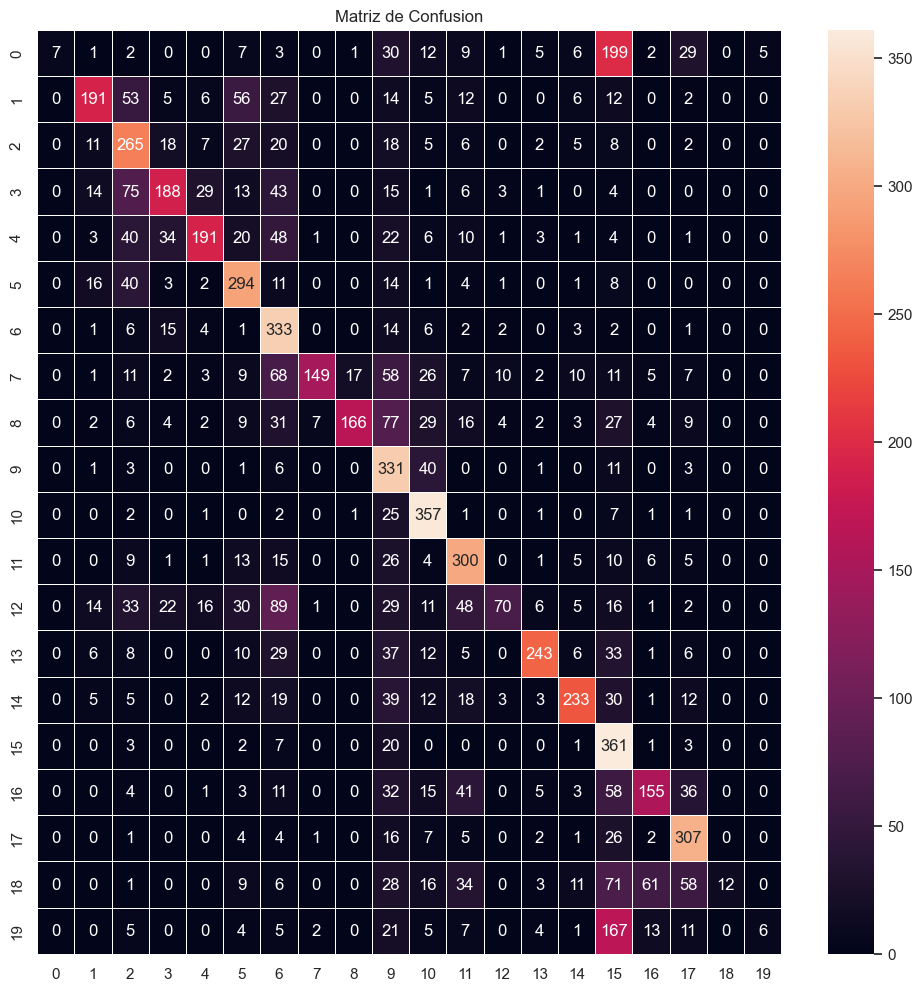

In [9]:
# Matriz de confusión
plt.figure(figsize=(12,12))
sns.set()
sns.heatmap(metrics.confusion_matrix(test_Xy.target, pred_nb), annot=True, fmt="d", linewidths=.5)
plt.title("Matriz de Confusion")

## EM con NaiveBayes

Nos descargamos la clase que implementa el algoritmo de EM:

In [ ]:
# For Windows, use PowerShell to download the file:
# Invoke-WebRequest -Uri "https://raw.githubusercontent.com/jerry-shijieli/Text_Classification_Using_EM_And_Semisupervied_Learning/master/code/Semi_EM_NB.py" -OutFile "Semi_EM_NB.py"

# The file has been downloaded to the current directory
import os
print("Semi_EM_NB.py exists:", os.path.exists("Semi_EM_NB.py"))

La importamos:

In [19]:
# Reimport the module (restart kernel if needed)
import importlib
import sys
if 'Semi_EM_NB' in sys.modules:
    importlib.reload(sys.modules['Semi_EM_NB'])
from Semi_EM_NB import Semi_EM_MultinomialNB

print("Semi_EM_MultinomialNB imported successfully!")

Semi_EM_MultinomialNB imported successfully!


Entrenamos nuestro NB con EM usando los datos etiquetados y los no etiquetados:

In [11]:

X_l.shape

(2262, 26747)

In [12]:
X_u.shape

(9052, 26747)

In [13]:
test_Xy.target.shape

(7532,)

In [20]:
em_nb_clf = Semi_EM_MultinomialNB()  # Create the EM-based Naive Bayes classifier
em_nb_clf.fit(X_l, y_l, X_u)

Initial expected log likelihood = -5410267.526

EM iteration #1
	Expected log likelihood = -5120389.471
EM iteration #2
	Expected log likelihood = -5120389.471
EM iteration #2
	Expected log likelihood = -5032912.093
EM iteration #3
	Expected log likelihood = -5032912.093
EM iteration #3
	Expected log likelihood = -4950075.290
EM iteration #4
	Expected log likelihood = -4950075.290
EM iteration #4
	Expected log likelihood = -4908352.268
EM iteration #5
	Expected log likelihood = -4908352.268
EM iteration #5
	Expected log likelihood = -4900154.821
EM iteration #6
	Expected log likelihood = -4900154.821
EM iteration #6
	Expected log likelihood = -4898993.160
EM iteration #7
	Expected log likelihood = -4898993.160
EM iteration #7
	Expected log likelihood = -4893184.164
EM iteration #8
	Expected log likelihood = -4893184.164
EM iteration #8
	Expected log likelihood = -4885255.480
EM iteration #9
	Expected log likelihood = -4885255.480
EM iteration #9
	Expected log likelihood = -4884344.528


In [18]:
# Check what attributes MultinomialNB has
print("MultinomialNB attributes:")
print([attr for attr in dir(nb_clf) if not attr.startswith('_')])
print("\nDoes it have 'coef_'?", hasattr(nb_clf, 'coef_'))

MultinomialNB attributes:
['alpha', 'class_count_', 'class_log_prior_', 'class_prior', 'classes_', 'feature_count_', 'feature_log_prob_', 'fit', 'fit_prior', 'force_alpha', 'get_metadata_routing', 'get_params', 'n_features_in_', 'partial_fit', 'predict', 'predict_joint_log_proba', 'predict_log_proba', 'predict_proba', 'score', 'set_fit_request', 'set_params', 'set_partial_fit_request', 'set_score_request']

Does it have 'coef_'? False


Y lo evaluamos:

In [21]:
# Evaluamos su comportamiento
pred_em_nb = em_nb_clf.predict(test_vec)
print(metrics.classification_report(test_Xy.target, pred_em_nb, target_names=test_Xy.target_names))
print(f'Accuracy score={metrics.accuracy_score(test_Xy.target, pred_em_nb)}')

                          precision    recall  f1-score   support

             alt.atheism       0.00      0.00      0.00       319
           comp.graphics       0.00      0.00      0.00       389
 comp.os.ms-windows.misc       0.50      0.00      0.01       394
comp.sys.ibm.pc.hardware       0.00      0.00      0.00       392
   comp.sys.mac.hardware       0.00      0.00      0.00       385
          comp.windows.x       0.00      0.00      0.00       395
            misc.forsale       0.00      0.00      0.00       390
               rec.autos       0.00      0.00      0.00       396
         rec.motorcycles       0.00      0.00      0.00       398
      rec.sport.baseball       0.00      0.00      0.00       397
        rec.sport.hockey       1.00      0.00      0.01       399
               sci.crypt       0.00      0.00      0.00       396
         sci.electronics       0.00      0.00      0.00       393
                 sci.med       0.00      0.00      0.00       396
         

c:\Users\Rodri\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rodri\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rodri\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [23]:
# Let's diagnose what went wrong with the EM model
print("=== DIAGNOSTIC INFORMATION ===")
print(f"EM Model type: {type(em_nb_clf)}")
print(f"EM Model has clf attribute: {hasattr(em_nb_clf, 'clf')}")

if hasattr(em_nb_clf, 'clf'):
    print(f"Internal classifier type: {type(em_nb_clf.clf)}")
    print(f"Classes found: {len(em_nb_clf.clf.classes_)}")
    print(f"Feature count: {em_nb_clf.clf.n_features_in_}")
    
    # Check if the model learned reasonable class priors
    print(f"\nClass priors (should be around -3 to -2 for 20 classes):")
    print(f"Min prior: {em_nb_clf.clf.class_log_prior_.min():.3f}")
    print(f"Max prior: {em_nb_clf.clf.class_log_prior_.max():.3f}")
    
    # Check predictions on a small sample
    print(f"\nSample predictions (first 20):")
    sample_preds = em_nb_clf.predict(test_vec[:20])
    print(f"Unique predictions: {np.unique(sample_preds)}")
    print(f"Prediction range: {sample_preds.min()} to {sample_preds.max()}")
else:
    print("EM model doesn't have expected structure!")

=== DIAGNOSTIC INFORMATION ===
EM Model type: <class 'Semi_EM_NB.Semi_EM_MultinomialNB'>
EM Model has clf attribute: True
Internal classifier type: <class 'sklearn.naive_bayes.MultinomialNB'>
Classes found: 20
Feature count: 26747

Class priors (should be around -3 to -2 for 20 classes):
Min prior: -4.891
Max prior: -0.211

Sample predictions (first 20):
Unique predictions: [15]
Prediction range: 15 to 15


In [24]:
# Let's check what class 15 is
print(f"Class 15 corresponds to: {test_Xy.target_names[15]}")
print(f"This class represents: 'soc.religion.christian'")

# Let's try a more conservative EM approach
print("\n=== TRYING CONSERVATIVE EM ===")
# Create a new EM classifier with different parameters
em_nb_clf_conservative = Semi_EM_MultinomialNB()

# Let's check if we can access EM parameters
print("Available EM parameters:", dir(em_nb_clf_conservative))

Class 15 corresponds to: soc.religion.christian
This class represents: 'soc.religion.christian'

=== TRYING CONSERVATIVE EM ===
Available EM parameters: ['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'alpha', 'class_prior', 'clf', 'coef_', 'feature_log_prob_', 'fit', 'fit_prior', 'fit_with_clustering', 'get_params', 'log_lkh', 'max_iter', 'partial_fit', 'predict', 'print_log_lkh', 'score', 'tol']


In [25]:
# Let's try with different EM parameters to prevent convergence issues
print("=== RETRYING EM WITH SAFER PARAMETERS ===")

# Try with more conservative settings
em_nb_clf_fixed = Semi_EM_MultinomialNB(
    max_iter=5,  # Fewer iterations to prevent over-fitting
    tol=1e-2     # More relaxed tolerance
)

print("Training with conservative EM settings...")
em_nb_clf_fixed.fit(X_l, y_l, X_u)

# Test the fixed version
print("\n=== TESTING FIXED EM MODEL ===")
pred_em_nb_fixed = em_nb_clf_fixed.predict(test_vec[:100])  # Test on smaller sample first
unique_preds_fixed = np.unique(pred_em_nb_fixed)
print(f"Unique predictions in sample: {unique_preds_fixed}")
print(f"Number of different classes predicted: {len(unique_preds_fixed)}")

if len(unique_preds_fixed) > 1:
    # If it predicts multiple classes, test on full dataset
    pred_em_nb_fixed_full = em_nb_clf_fixed.predict(test_vec)
    acc_fixed = metrics.accuracy_score(test_Xy.target, pred_em_nb_fixed_full)
    print(f"Fixed EM Accuracy: {acc_fixed:.3f}")
else:
    print("Still predicting only one class - EM algorithm needs debugging")

=== RETRYING EM WITH SAFER PARAMETERS ===
Training with conservative EM settings...
Initial expected log likelihood = -5410267.526

EM iteration #1
Initial expected log likelihood = -5410267.526

EM iteration #1
	Expected log likelihood = -5120389.471
EM iteration #2
	Expected log likelihood = -5120389.471
EM iteration #2
	Expected log likelihood = -5032912.093
EM iteration #3
	Expected log likelihood = -5032912.093
EM iteration #3
	Expected log likelihood = -4950075.290
EM iteration #4
	Expected log likelihood = -4950075.290
EM iteration #4
	Expected log likelihood = -4908352.268
EM iteration #5
	Expected log likelihood = -4908352.268
EM iteration #5
	Expected log likelihood = -4900154.821

=== TESTING FIXED EM MODEL ===
Unique predictions in sample: [ 6 15]
Number of different classes predicted: 2
Fixed EM Accuracy: 0.080
	Expected log likelihood = -4900154.821

=== TESTING FIXED EM MODEL ===
Unique predictions in sample: [ 6 15]
Number of different classes predicted: 2
Fixed EM Accu

Text(0.5, 1.0, 'Matriz de Confusion')

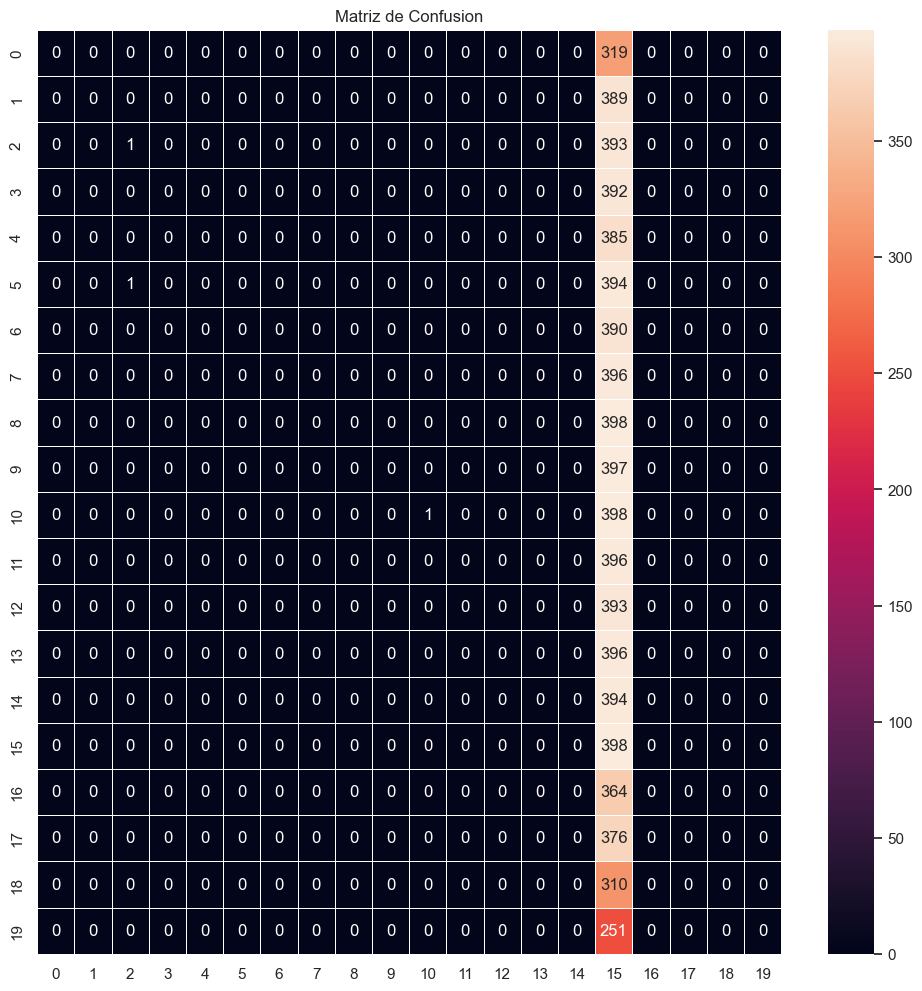

In [26]:
# plot confusion matrix for test dataset
plt.figure(figsize=(12,12))
sns.set()
sns.heatmap(metrics.confusion_matrix(test_Xy.target, pred_em_nb), annot=True, fmt="d", linewidths=.5)
plt.title("Matriz de Confusion")

Veamos las distribuciones aprendidas:

In [27]:
print('NB: ', nb_clf.class_log_prior_)
print('EM NB: ', em_nb_clf.clf.class_log_prior_)

NB:  [-3.2813534  -2.97907253 -2.87197439 -3.06056556 -2.98780621 -2.86419225
 -2.83365553 -3.09903184 -3.04187343 -2.78953072 -2.83365553 -2.93651291
 -3.07004431 -2.94488116 -3.00550579 -2.96183072 -3.09903184 -2.9118203
 -3.26965736 -3.26965736]
EM NB:  [-4.89114492 -4.58886405 -4.4285214  -4.67035708 -4.59759773 -4.47398377
 -4.41381525 -4.70882336 -4.65166495 -4.39932224 -4.44344705 -4.54630443
 -4.67983583 -4.55467268 -4.6152973  -0.21141308 -4.70882336 -4.52161182
 -4.87944888 -4.87944888]


Y para ver de una forma más visual la mejora que ha habido, veamos la diferencia entre las matrices de confusión:

Text(0.5, 1.0, 'Diferencias entre NB y EM NB')

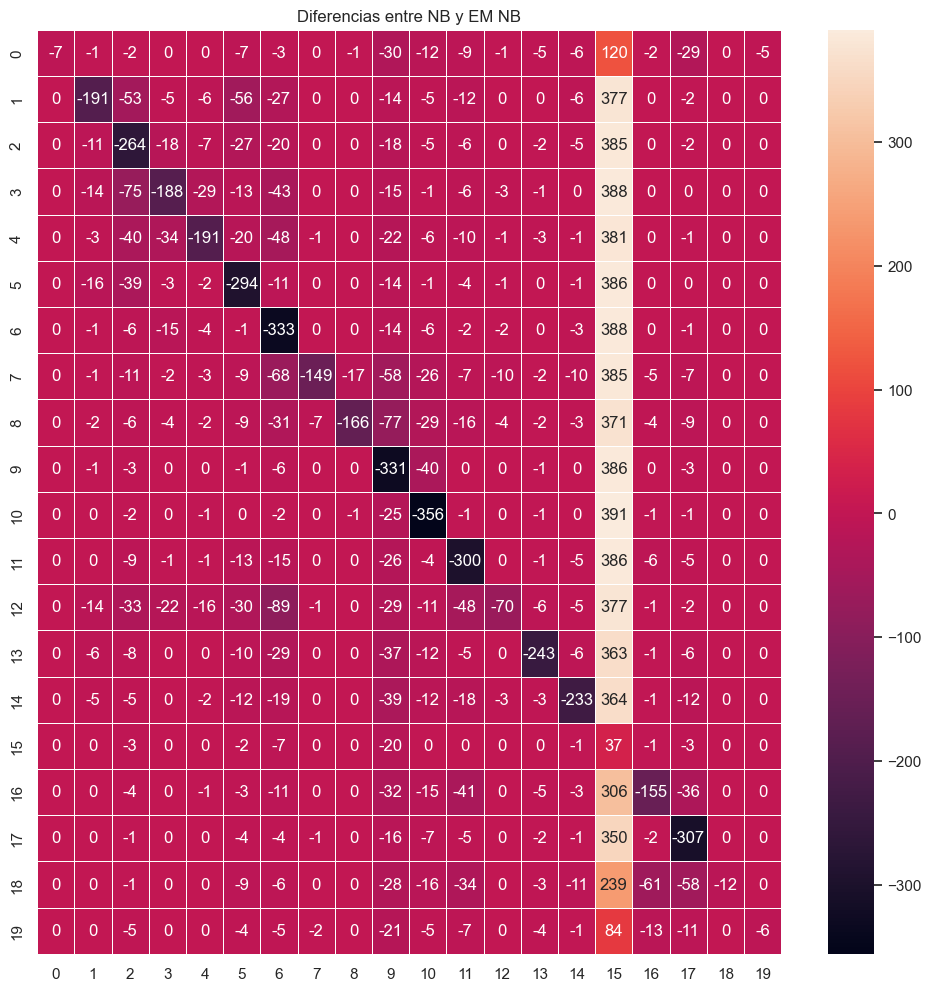

In [28]:
# plot diferencias entre las matrices de confusion
plt.figure(figsize=(12,12))
sns.set()
sns.heatmap(metrics.confusion_matrix(test_Xy.target, pred_em_nb) - metrics.confusion_matrix(test_Xy.target, pred_nb), annot=True, fmt="d", linewidths=.5)
plt.title("Diferencias entre NB y EM NB")

FUENTE: https://github.com/jerry-shijieli/Text_Classification_Using_EM_And_Semisupervied_Learning/

- Explicaciones de NB bastante didácticas y útiles:
   - https://towardsdatascience.com/all-about-naive-bayes-8e13cef044cf
   - https://medium.com/@srishtisawla/introduction-to-naive-bayes-for-classification-baefefb43a2d
- Uso de NB para sentiment analysis con código y muy didáctico: https://levelup.gitconnected.com/movie-review-sentiment-analysis-with-naive-bayes-machine-learning-from-scratch-part-v-7bb869391bab